# Lab: Building a Reproducible Analysis Workflow

In the first part of this lab, you will use official National Park Service data to answer a guided question. In the second part, you will find a dataset and conduct an analysis of your own.

Use the workflow from lecture throughout the lab:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

By the end of this lab, you should be able to:

- organize an investigation with the reproducible analysis workflow;
- inspect a dataset before analyzing it;
- group, summarize, check, and sort observations with Pandas;
- formulate a research question that can be answered with data; and
- distinguish evidence, conclusions, and limitations.


## Using AI tools responsibly

You may use AI to ask questions, debug code, or receive feedback. You remain responsible for understanding your work, verifying suggestions against the data, and citing the source of your dataset. At the end, disclose whether you used an AI tool. Using AI is not required.


# Part 1: Florida park visitation


## Background

The National Park Service (NPS) publishes estimates of recreational visits to its units. These estimates help parks understand patterns in public use and plan staffing, maintenance, transportation, and visitor services.

This course file contains monthly estimates for five Florida NPS units from 2015 through 2025:

- Big Cypress National Preserve
- Biscayne National Park
- Canaveral National Seashore
- Dry Tortugas National Park
- Everglades National Park

A recreational visit is a visit, not necessarily one unique person. A person who visits several times may be counted several times.


| Feature | Description |
| --- | --- |
| `park_code` | Four-letter NPS unit code |
| `park` | Name of the NPS unit |
| `year` | Calendar year of the observation |
| `month_number` | Month represented as an integer from 1 through 12 |
| `month` | Month name |
| `recreation_visits` | Estimated recreational visits during that park-month |


## Step 1: Question

**After the decline in July 2020, when did Canaveral National Seashore's July recreational visitation first return to or exceed its average July visitation from 2015–2019?**

The 2015–2019 mean provides a pre-pandemic comparison point. In this question, “recovery” means the first July from 2020 onward with visitation at or above that baseline. This definition does not require every later July to remain above the baseline.


## Step 2: Data

Import Pandas using the alias `pd`. Read `data/nps_florida_park_visitation_2015_2025.csv` into a DataFrame named `park_visits`, then display its first five rows.


In [1]:
# Write your code here.
import pandas as pd

park_visits = pd.read_csv('data/nps_florida_park_visitation_2015_2025.csv')

park_visits.head(5)

,park_code,park,year,month_number,month,recreation_visits
0,BICY,Big Cypress National Preserve,2015,1,January,114045
1,BICY,Big Cypress National Preserve,2015,2,February,144112
2,BICY,Big Cypress National Preserve,2015,3,March,153084
3,BICY,Big Cypress National Preserve,2015,4,April,113880
4,BICY,Big Cypress National Preserve,2015,5,May,72510


Display the last five rows.


In [2]:
# Write your code here.
park_visits.tail(5)


,park_code,park,year,month_number,month,recreation_visits
655,EVER,Everglades National Park,2025,8,August,50464
656,EVER,Everglades National Park,2025,9,September,32290
657,EVER,Everglades National Park,2025,10,October,19008
658,EVER,Everglades National Park,2025,11,November,53416
659,EVER,Everglades National Park,2025,12,December,70926


Display information about the DataFrame and calculate the number of missing observations in each feature.


In [3]:
# Write your code here.
park_visits.info()
park_visits.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   park_code          660 non-null    str  
 1   park               660 non-null    str  
 2   year               660 non-null    int64
 3   month_number       660 non-null    int64
 4   month              660 non-null    str  
 5   recreation_visits  660 non-null    int64
dtypes: int64(3), str(3)
memory usage: 54.1 KB


park_code            0
park                 0
year                 0
month_number         0
month                0
recreation_visits    0
dtype: int64

**What does each row represent?**

Your answer: Monthly total visits to a specific park 


**Are any observations missing from the six features?**

Your answer: No


## Step 3: Operation

Create one Boolean condition that identifies Canaveral National Seashore and another that identifies July.


In [4]:
# Write your code here.
CANA = park_visits['park_code'] == 'CANA'
CANA.head(5)

July = park_visits['month_number'] == 7
July.head(5)

0    False
1    False
2    False
3    False
4    False
Name: month_number, dtype: bool

Combine the two conditions with `&`. Use `.loc` to select the `year` and `recreation_visits` features, make a copy named `canaveral_july`, and display it.


In [5]:
# Write your code here.
annual_visits = CANA & July

annual_visits.value_counts()

canaveral_july = park_visits.loc[annual_visits, ['year', 'recreation_visits']].copy()

canaveral_july

,year,recreation_visits
270,2015,163169
282,2016,216437
294,2017,138018
306,2018,189285
318,2019,162947
330,2020,112898
342,2021,206636
354,2022,233352
366,2023,173296
378,2024,176242


Create `pre_pandemic_condition`, which is `True` for years from 2015 through 2019. Use it with `.loc` to calculate the mean of `recreation_visits`, and store the result as `pre_pandemic_july_mean`.

Display `pre_pandemic_july_mean`.


In [6]:
# Write your code here.
pre_pandemic_condition = (canaveral_july['year'] >= 2015) & (canaveral_july['year'] <= 2019)

pre_pandemic_condition.value_counts()

pre_pandemic_july_mean = canaveral_july.loc[pre_pandemic_condition, 'recreation_visits'].mean()

pre_pandemic_july_mean

np.float64(173971.2)

Create a condition that identifies rows from 2020 onward whose `recreation_visits` are greater than or equal to `pre_pandemic_july_mean`. Use `.loc` to create `recovery_years`, then display it in ascending year order.


In [7]:
# Write your code here.
post_pandemic_condition = (canaveral_july['year'] >= 2020) & (canaveral_july['recreation_visits'] >= pre_pandemic_july_mean)

post_pandemic_condition.value_counts()

recovery_years = canaveral_july.loc[post_pandemic_condition].sort_values('year', ascending=True)

recovery_years

,year,recreation_visits
342,2021,206636
354,2022,233352
378,2024,176242
390,2025,253403


## Step 4: Check

Display the number of rows in `canaveral_july`, its smallest year, and its greatest year.


In [8]:
# Write your code here.
len(canaveral_july), canaveral_july['year'].min(), canaveral_july['year'].max()


(11, np.int64(2015), np.int64(2025))

**Do these results confirm that the filtered data contains one July observation for every year from 2015 through 2025?**

Your answer:


Count the observations used to calculate `pre_pandemic_july_mean`.


In [9]:
# Write your code here.
pre_pandemic_condition.sum()

np.int64(5)

**Does the baseline use the expected five years?**

Your answer: Yes


## Step 5: Evidence

Display the first row of `recovery_years`.


In [10]:
# Write your code here.
recovery_years.head(1)
canaveral_july


,year,recreation_visits
270,2015,163169
282,2016,216437
294,2017,138018
306,2018,189285
318,2019,162947
330,2020,112898
342,2021,206636
354,2022,233352
366,2023,173296
378,2024,176242


**What was the 2015–2019 mean, and which year first met or exceeded it after the July 2020 decline? Report that year's July visitation.**

Your answer: The mean was 173971.2 visits. July 2021 was the first year to exceed it with a total of 206636 visits


## Step 6: Conclusion


**Write one sentence that answers the research question using the evidence.**

Your answer: Canaveral National Seashore first exceeded the pre-pandemic mean of 173971.2 visits by recording 206636 visits for the month of July 2021.

## Step 7: Limitation


**Does first exceeding the baseline mean that every later July remained above it? Use the data to explain.**

Your answer: No. In fact, it fell slightly below the pre-pandemic mean in July 2023 with a total of 173296 visits.


**Why does this analysis alone not establish that the pandemic caused the 2020 decline?**

Your answer: While it's easy to draw that conclusion, the numbers don't paint a complete picture as there's no indication of what caused the decline. Looking at canaveral_july, there were many years(2015, 2017, 2019) that fell short of the pre-pandemic mean. This data raises follow up questions as to what conditions each July faced. Natural events like hurricanes are a major factor in Florida, for example.


# Part 2: Your own investigation


## Find a dataset

Find a CSV dataset that interests you. Kaggle is one possible source, but you may use another reputable source. Choose a dataset that:

- has a clearly identified publisher or creator;
- includes documentation explaining the observations and features;
- contains at least one categorical and one quantitative feature;
- is appropriate to share in a class assignment;
- does not contain private or personally identifying information; and
- is small enough to run comfortably in this notebook.

Save the CSV in the notebook's `data` folder before continuing.


**What is the dataset's title, publisher or creator, and direct source URL?**

Your answer: Video Game Sales, Anand Shaw, https://www.kaggle.com/datasets/anandshaw2001/video-game-sales


**What does one row represent?**

Your answer: A single game title and its regional sales on a given platform


## Step 1: Question

Formulate one research question that can be answered with your dataset. The question must require a calculation or comparison, not merely looking up one value.


**What is your research question?**

Your answer: Which game titles recorded the highest global sales on the PlayStation 2?


## Step 2: Data

Read your CSV into a clearly named DataFrame. Display the first and last five rows, information about the DataFrame, and the missing-value count for every feature.


In [11]:
# Write your code here.
game_sales = pd.read_csv('data/vgsales.csv')

display(game_sales.head(5))

display(game_sales.tail(5))

game_sales.info()

game_sales.isnull().sum()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

**Which observations and features will you use to answer your question?**

Your answer: All rows where PS2 is the platform using these columns: Name, Year, Global_Sales.


## Step 3: Operation

Write the code needed to prepare, filter, group, summarize, or sort the data. Store the final evidence in a clearly named object and display it.


,Name,Year,Global_Sales,Sales_Pct
17,Grand Theft Auto: San Andreas,2004.0,20.81,1.657322
24,Grand Theft Auto: Vice City,2002.0,16.15,1.286197
28,Gran Turismo 3: A-Spec,2001.0,14.98,1.193017
38,Grand Theft Auto III,2001.0,13.10,1.043293
47,Gran Turismo 4,2004.0,11.66,0.928610
86,Final Fantasy X,2001.0,8.05,0.641107
104,Need for Speed Underground,2003.0,7.20,0.573413
113,Need for Speed Underground 2,2004.0,6.90,0.549521
114,Medal of Honor: Frontline,2002.0,6.83,0.543946
131,Kingdom Hearts,2002.0,6.40,0.509700


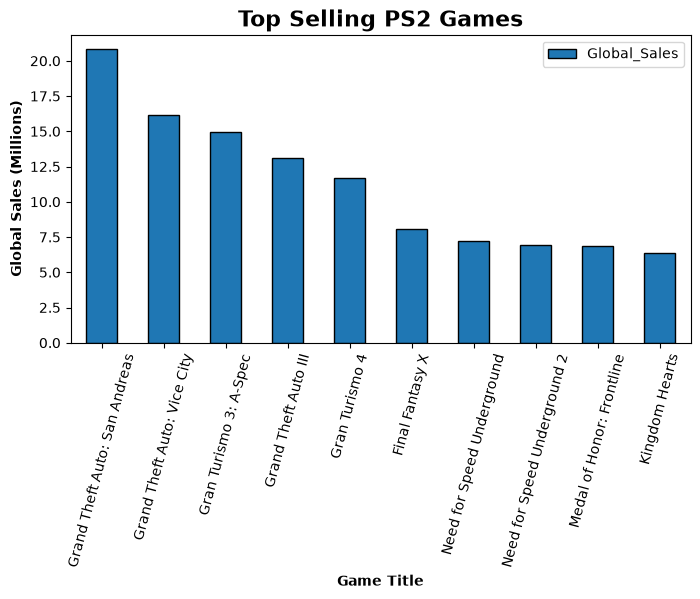

In [12]:
# Write your code here.
ps2_game_sales = game_sales[game_sales['Platform'] == 'PS2'].copy()

top_ps2_games = ps2_game_sales[['Name', 'Year', 'Global_Sales']].sort_values(by='Global_Sales', ascending=False).copy()

total_ps2_global_sales = top_ps2_games['Global_Sales'].sum()

top_ps2_games['Sales_Pct'] = (top_ps2_games['Global_Sales'] / total_ps2_global_sales) * 100

ps2_best_sellers = top_ps2_games[top_ps2_games['Sales_Pct'] >= 0.5].copy()

display(ps2_best_sellers.head(10))

import matplotlib.pyplot as plt

ps2_best_sellers.plot(kind='bar', x ='Name', y ='Global_Sales', edgecolor ='black', figsize=(8, 4))
plt.ylabel('Global Sales (Millions)', weight = 'bold')
plt.xlabel('Game Title', weight = 'bold')
plt.title('Top Selling PS2 Games', size = 16, weight='bold')
plt.xticks(rotation = 75)
plt.show()


**Explain how your operations connect the selected data to your research question.**

Your answer: Taking the sample and filtering for just the PlayStation 2 platform allowed me to drill down to find all the games sold on the console. I added a feature to quantify each title's market share. I targeted 0.5% as the basis to describe the top sellers. This yielded 10 game titles that spanned over the 2001 to 2004 period of the console's lifespan. These were unquestionably games with the highest global sales on the PS2.


## Step 4: Check

Write at least one check that could reveal an error in your analysis, then display its result.


In [13]:
# Write your code here.

top_ps2_games[['Name', 'Year', 'Global_Sales']].isnull().sum()

Name             0
Year            34
Global_Sales     0
dtype: int64

**What did you check, and did the result meet your expectation?**

Your answer: I checked to see if any observations were missing features that could corrupt my findings. 34 rows were missing an entry for "Year". Since the goal was to find total global sales, which had no missing values, the results met my expectations.


## Step 5: Evidence


**Which specific value or comparison in your output answers the question?**

Your answer: By setting a 0.5% threshold, the console's top performers were clearly distinguished from the rest. This cohort which included GTA:San Andreas (20.81M) at the top and Kingdom Hearts (6.4M) at the bottom, accounted for over 111M of the console's 1.25B global sales. 


## Step 6: Conclusion


**What conclusion is supported by the evidence?**

Your answer: Almost 1 in every 10 games sold belonged to this group. It's startling how 3 third party publishers(Rockstar, EA, Square) make up 80% of the list.


## Step 7: Limitation


**What should a reader avoid concluding from your analysis, and why?**

Your answer: Overstating the case for these types of games. Many companies tried and failed to replicate what these titles did since they were so massively dominant. The numbers don't factor in why these were successful. They just state their sales. The other 90% of games sold also contributed to the PS2's record setting popularity.


## AI-use reflection


**State whether you used an AI tool. If you did, describe one suggestion you checked and what you accepted, changed, or rejected. If you did not, state that you did not use one.**

Your response: When looking for a dataset, I asked what a good dataset would be for a lab about data analysis. It suggested keeping the filesize below 500KB to keep pandas responsive so when I went to Kaggle, I started with a default search that returned over 700k entries. I then set the max size to 500K which brought it down to 256K. I entered "game" as my query which narrowed it considerably to just over 2.5k. When I loaded the csv, it went smoothly so I credit Google for suggesting the file size.


## Submission checklist

Before submitting, confirm that all cells run in order, the independent dataset and its source are included, every answer is complete, numerical claims match the output, conclusions are appropriately limited, and the AI-use reflection is complete.
